# Guardian Coverage of Russell Group Universities (2010–2024)

**ST115 Managing and Visualising Data — Final Report**

In [55]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib
import seaborn as sns

sns.set_style("darkgrid")
matplotlib.rcParams['figure.figsize'] = (10, 6)

In [4]:
#loading the combined dataset 
df = pd.read_csv('data/raw/combined_raw.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Shape: (25142, 7)
Columns: ['university', 'id', 'webPublicationDate', 'sectionId', 'sectionName', 'webTitle', 'wordcount']


# 1 Introduction

## 1.1 Motivation

Universities are central to public life in the UK. Debates around tuition fees, research funding, immigration, and student welfare regularly make national news. The Guardian is one of the UK's most widely read broadsheet newspapers and covers higher education widely. 

We were interested in whether Guardian coverage of universities is concentrated among a small number of institutions, and how that has changed over time, and whether major UK events produce visible spikes in coverage. These are questions we can answer using data from the Guardian API, which we learnt about in the course. 

## 1.2 Research Questions 

We have three main research questions:
1. Which Russell Group universities receive the most Guardian coverage, and how has that changed over time (2010-2024)?
2. What topics dominate coverage of the top universities, and do they differ across institutions? 
3. How does coverage spike around major UK events, such as Brexit, COVID-19, and tuition fee changes?

## 1.3 Why Russell Group Universities? Why these 10?

The Russell Group is a group of 24 research-intensive universities in the UK. They are the universities most likely to appear regularly in national press coverage, so we expected enough articles per university to make meaningful comparisons over time.
    
Rather than analysing all 24, we narrowed our focus to the top 10 by total Guardian article count between 2010 and 2024. This keeps the project manageable while still covering a range of institution types. The bar chart in data_collection.ipynb shows article counts across all Russell Group universities. There is a clear drop-off after the 10th university, which justifies our cut-off. We could not find existing work that compares Guardian coverage across Russell Group universities over a 15-year period. We considered supplementing the Guardian data with a second source, such as HESA student enrolment statistics or the Complete University Guide rankings, to provide context for the coverage patterns we observe. However, we decided that introducing external data would shift the analysis towards correlation rather than description, which is beyond the scope of this course. We note this as a possible extension in Section 5.3.


## 1.4 Limitations of the search approach

We searched for each university using its full name in quotes (e.g. "University of Oxford"), which returns only articles containing the exact phrase. This means articles that use abbreviations or informal names may be missed - for example, an article mentioning "Oxford" but not "University of Oxford" would not appear in our results. Similarly, searching for "London School of Economics" will not capture articles that only refer to "LSE". We also note that "LSE" can refer to the London Stock Exchange, so using the full name avoids false matches. This means we may miss some relevant articles, but we avoid picking up irrelevant ones like articles about the London Stock Exchange.

# 2 Data Acquisition

## 2.1 The Guardian API 
We collected our data using the Guardian Open Platform API (https://open-platform.theguardian.com/documentation/). This is a free API that gives structured access to Guardian articles. To use it, we registered for a developer API key at https://open-platform.theguardian.com/access/ and stored the key in a keys.json file. 

The API returns data in JSON format. Each response contains a response object with the total number of matching articles, the number of pages, the current page, and a list of article results. By default it returns 10 results per page - we increased this to 50 using the page-size parameter. We restricted our search to articles published between 1 January 2010 and 31 December 2024, giving a 15-year window that covers several major UK events including the 2010 tuition fee protests, Brexit (2016), and COVID-19 (2020).

## 2.2 Fields Collected 
We collected the following fields for each article: id, webPublicationDate, sectionId, sectionName, webTitle, and wordcount. The wordcount field is not returned by default and had to be requested using the show-fields parameter. We also added a university column to track which search query each article came from. 

We also collected bodyText during the original data collection run, but excluded it from the saved CSV because the file would exceed GitHub's 100MB limit. The full data including body text can be reproduced by running data_collection.ipynb. 

## 2.3 Querying the API

In [ ]:
#example only - do not run
import requests
import json

#load API key from keys.json
with open('keys.json') as f:
    keys = json.load(f)
guardian_api_key = keys['guardian']['api_key']

#single request for University College London articles, page 1
r = requests.get(
    'https://content.guardianapis.com/search',
    params={
        'q': '"University College London"',
        'api-key': guardian_api_key,
        'order-by': 'oldest',
        'from-date': '2010-01-01',
        'to-date': '2024-12-31',
        'page-size': 50,
        'page': 1,
        'show-fields': 'wordcount,bodyText'
    }
)

print('Status code:', r.status_code)
response = r.json()['response']
print('Total articles:', response['total'])
print('Total pages:', response['pages'])

## 2.4 Pagination 

Because each university has hundreds or thousands of articles, we could not get them all in one request. We used pagination to loop through all pages, incrementing the page parameter on each iteration and stopping when currentPage reached pages.

We also handled the rate limit (HTTP status 429) by pausing for 60 seconds and retrying, as demonstrated in the lecture. The full loop for all 10 universities is in data_collection.ipynb. A simplified version is shown below for illustration:

In [56]:
#simplified pagination loop (not run here - see data_collection.ipynb for the full version)
import time

results = []
page = 1

#paginate through all pages of results
while True:
    try:
        r = requests.get(
            'https://content.guardianapis.com/search',
            params={
                'q': '"University College London"',
                'api-key': guardian_api_key,
                'order-by': 'oldest',
                'page': page,
                'page-size': 50,
                'from-date': '2010-01-01',
                'to-date': '2024-12-31',
                'show-fields': 'wordcount,bodyText'
            }
        )

        #successful response
        if r.status_code == 200:
            response = r.json()['response']
            results.append(response)
            print(f'Collected data from page {page}.')
            #stop if we've reached the last page
            if response['currentPage'] >= response['pages']:
                break
            time.sleep(1)  #wait 1 second between requests
            page += 1

        #rate limit hit - wait and retry the same page
        elif r.status_code == 429:
            print('Rate limit reached, waiting for 60 seconds')
            time.sleep(60)

        #something else went wrong
        else:
            print(f'Unexpected status code {r.status_code} on page {page}. Stopping.')
            break

    except Exception as e:
        print(f'Failed to collect data for page {page}. Error: {e}')
        break

## 2.5 Data Storage 

After collecting all articles for all 10 universities, we combined them into a single DataFrame and saved it to: 
data/raw/combined_raw.csv 

This file has 25,142 rows and 7 columns: university, id, webPublicationDate, sectionId, sectionName, webTitle, and wordcount. The bodyText column was not saved due to the Github file size limit but can be reproduced by re-running data_collection.ipynb. 

The full data collection process, including the complete pagination loop for all 10 universities and the code to flatten and save the JSON responses, is documented in data_collection.ipynb. 

To reproduce the data collection: save your Guardian API key in a file called keys.json in the project root directory, formatted as {"guardian": {"api_key": "YOUR_KEY"}}. Then run data_collection.ipynb. Note that the full collection takes approximately 30 minutes due to rate limiting.

# 3 Data Preparation and Initial Data Analysis

This section prepares and explores the raw Guardian dataset. 
The focus is on data cleaning, basic data quality checks, and creating variables for further analysis.

## 3.1 Basic data quality checks

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25142 entries, 0 to 25141
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   university          25142 non-null  object
 1   id                  25142 non-null  object
 2   webPublicationDate  25142 non-null  object
 3   sectionId           25142 non-null  object
 4   sectionName         25142 non-null  object
 5   webTitle            25142 non-null  object
 6   wordcount           25142 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 1.3+ MB


In [10]:
df.isna().sum()

university            0
id                    0
webPublicationDate    0
sectionId             0
sectionName           0
webTitle              0
wordcount             0
dtype: int64

In [11]:
#check for full-row duplicates
print("Full-row duplicates:", df.duplicated().sum())

Full-row duplicates: 0


In [12]:
#check for cross-university article overlap
#the same Guardian article can mention multiple universities,
#so it may appear under more than one university search
print(f"Total rows: {len(df)}")
print(f"Unique article IDs: {df['id'].nunique()}")

#find articles that appear more than once
dup_mask = df['id'].duplicated(keep=False)
dup_articles = df[dup_mask]
print(f"Rows with shared article IDs: {len(dup_articles)}")

#how many universities does each shared article appear under?
unis_per_article = dup_articles.groupby('id')['university'].nunique()
print(f"\nShared across 2 universities: {(unis_per_article == 2).sum()}")
print(f"Shared across 3+ universities: {(unis_per_article >= 3).sum()}")

#show an example
sample_id = dup_articles['id'].iloc[0]
print(f"\nExample - article ID: {sample_id}")
df[df['id'] == sample_id][['university', 'webTitle']]

Total rows: 25142
Unique article IDs: 22021
Rows with shared article IDs: 5411

Shared across 2 universities: 1800
Shared across 3+ universities: 490

Example - article ID: service-design/polymorphs


,university,webTitle
8,University of Birmingham,Polymorphs in the making
19965,University College London,Polymorphs in the making


### Cross-university article overlap

There are no full-row duplicates, but 5,411 rows (21.5% of the dataset) share an article ID with at least one other row. This is not an error - it occurs because a single Guardian article can mention multiple universities (e.g. an article about Oxford–Cambridge collaboration appears under both searches).

All 2,290 shared articles appear under different universities, never the same one twice, confirming our data collection was clean.

Handling decision: We keep all rows for per-university analysis, since each row represents a mention of that university in the Guardian. However, we note that summing article counts across all universities will overcount the total number of unique articles. Where total counts matter (e.g. overall yearly trends), we will use deduplicated data.

In [13]:
df["wordcount"].describe()

count    25142.000000
mean      1423.447975
std       2471.551938
min          0.000000
25%        599.000000
50%        809.000000
75%       1134.750000
max      42709.000000
Name: wordcount, dtype: float64

In [14]:
#investigate articles with wordcount = 0
zero_wc = df[df['wordcount'] == 0]
print(f"Articles with wordcount = 0: {len(zero_wc)}")
print(f"\nThese are typically video or interactive content:")
zero_wc[['university', 'webTitle', 'sectionName']].head(8)

Articles with wordcount = 0: 60

These are typically video or interactive content:


,university,webTitle,sectionName
3,University of Birmingham,Video: Why the good guys draw faster in a gunf...,Science
67,University of Birmingham,Scientists create invisibility cloak - video,Science
273,University of Birmingham,Gay marriage in Britain: a history - student f...,Education
336,University of Birmingham,Is an arts degree worth the tuition fees? - fi...,Opinion
356,University of Birmingham,Tackling creationism head-on in science lesson...,Science
1455,University of Bristol,Love song of a Jurassic cricket - video,Science
1593,University of Bristol,Danceroom Spectroscopy: dancing molecules brin...,Science
2706,University of Cambridge,'There's a responsibility for people who look ...,Opinion


### Wordcount = 0 articles

60 articles have a wordcount of zero. Inspecting them reveals they are video content (the titles contain "video", "film", etc.). These are legitimate Guardian content but contain no article text. We retain them in the dataset since they still represent media coverage, but they should be excluded from any analysis that uses wordcount as a variable.

### Summary of data quality checks

Initial inspection reveals:
- No missing values across all seven variables.
- No full-row duplicates, but 5,411 rows share an article ID with another row due to cross-university overlap. This is expected and handled as described above.
- 60 articles have wordcount = 0, corresponding to video content.
- The wordcount distribution is right-skewed (median 809, mean 1,423, max 42,709), which is typical for article length data.
- The dataset contains both categorical variables (university, sectionId, sectionName, webTitle) and one numerical variable (wordcount), plus a datetime string (webPublicationDate) that requires conversion.

### Coverage check: articles per university per year


In [16]:
#check that each university has reasonable coverage across all years
df['year'] = pd.to_datetime(df['webPublicationDate']).dt.year
coverage = pd.crosstab(df['university'], df['year'])
coverage

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
university,,,,,,,,,,,,,,,
Cardiff University,157,143,111,116,88,121,102,103,64,76,86,79,70,49,66
Imperial College London,122,132,152,157,172,126,153,130,144,100,435,425,218,186,145
London School of Economics,292,437,357,293,308,333,322,254,207,186,269,209,170,177,166
University College London,318,366,307,328,380,399,343,297,293,285,539,477,276,321,298
University of Birmingham,61,96,93,106,111,93,87,79,89,78,125,94,71,63,69
University of Bristol,48,87,77,87,85,84,90,68,69,79,136,166,86,94,88
University of Cambridge,67,121,124,169,170,157,178,152,157,160,207,218,151,190,167
University of Edinburgh,69,79,56,82,100,86,106,87,89,78,243,232,136,118,101
University of Manchester,74,100,98,170,139,164,134,152,118,123,124,141,99,104,88


All 10 universities have articles in every year from 2010 to 2024, with no gaps. Coverage is uneven — UCL and LSE consistently have the most articles per year — but no university drops to zero in any period, confirming the dataset supports time-series comparisons across all 15 years.


## 3.2 Data cleaning

In [66]:
clean_df = df.copy()

# remove duplicates
clean_df = clean_df.drop_duplicates()

# convert date to datetime
clean_df["webPublicationDate"] = pd.to_datetime(clean_df["webPublicationDate"])

# remove bad dates
clean_df = clean_df.dropna(subset=["webPublicationDate"])

# create time variables
clean_df["year"] = clean_df["webPublicationDate"].dt.year
clean_df["month"] = clean_df["webPublicationDate"].dt.month
clean_df["year_month"] = clean_df["year"].astype(str) + "-" + clean_df["month"].astype(str).str.zfill(2)

# clean wordcount
clean_df["wordcount"] = pd.to_numeric(clean_df["wordcount"])
clean_df = clean_df.dropna(subset=["wordcount"])
clean_df = clean_df[clean_df["wordcount"] >= 0]

print(clean_df.shape)
clean_df.head()

(25142, 10)


,university,id,webPublicationDate,sectionId,sectionName,webTitle,wordcount,year,month,year_month
0,University of Birmingham,theguardian/2010/jan/03/simonedebeauvoir-oxfor...,2010-01-03 18:36:43+00:00,global,Global,elizabeth fallaize obituary,1007,2010,1,2010-01
1,University of Birmingham,education/2010/jan/19/gel-curb-appetite-scient...,2010-01-19 00:05:05+00:00,education,Education,food scientists develop appetite-curbing gel,839,2010,1,2010-01
2,University of Birmingham,science/2010/jan/25/mary-english-obituary,2010-01-25 18:38:39+00:00,science,Science,mary english obituary,931,2010,1,2010-01
3,University of Birmingham,science/video/2010/feb/03/good-guys-draw-faste...,2010-02-03 04:50:00+00:00,science,Science,video: why the good guys draw faster in a gunf...,0,2010,2,2010-02
4,University of Birmingham,education/2010/feb/06/cv-clinic-jenny-adams,2010-02-06 00:05:03+00:00,education,Education,cv clinic,552,2010,2,2010-02


### Cleaning decisions

- Duplicate rows: Full-row duplicates were checked and none were found. Cross-university article overlaps (same article ID, different university) are retained as discussed in the IDA section above.
- Date conversion: The publication date was converted from string to datetime to enable time-based grouping and filtering.
- New time variables: year, month, and year_month (as "YYYY-MM" period strings) were created to support aggregation at different time resolutions.
- Wordcount validation: Converted to numeric and verified no negative values exist. Articles with wordcount = 0 (video content) are retained but flagged.
- No rows were dropped during cleaning, as no missing values or invalid entries were found. The cleaned dataset has the same 25,142 rows as the raw data.

## 3.3 Distribution by section

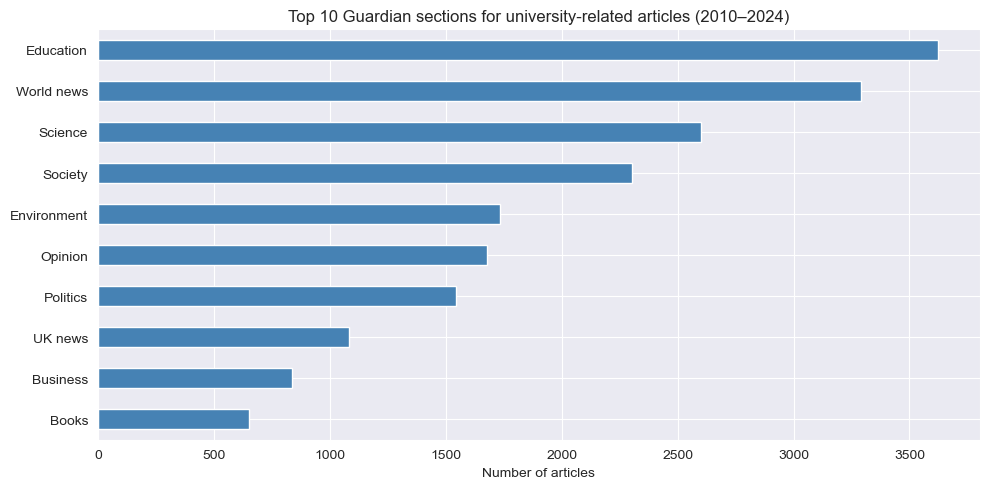

In [67]:
section_counts = clean_df["sectionName"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
section_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")

ax.set_title("Top 10 Guardian sections for university-related articles (2010–2024)", fontsize=12)
ax.set_xlabel("Number of articles")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretation

The distribution shows that articles are concentrated in a small number of sections, particularly education, world news, and science.\
This indicates that university-related topics appear across multiple sections rather than being confined to a single category.

## 3.4 Articles over time

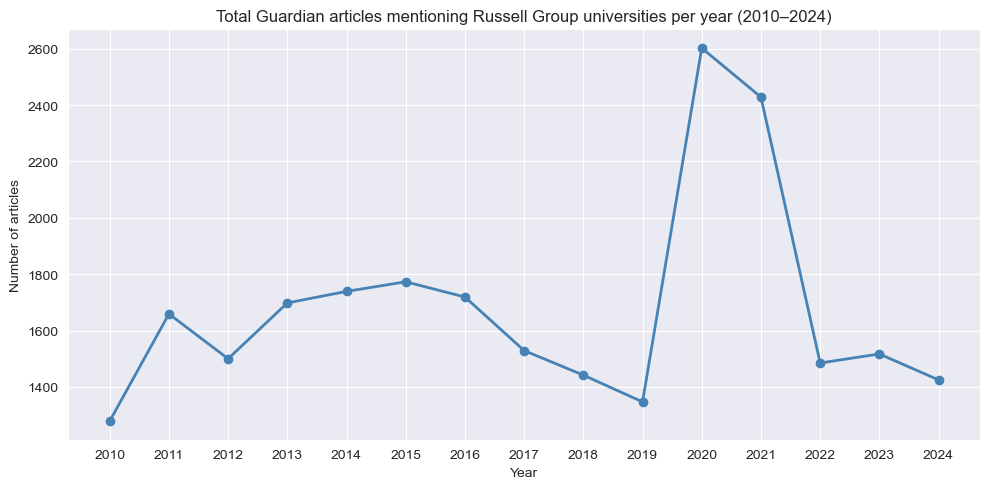

In [68]:
yearly_counts = clean_df.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_counts.index, yearly_counts.values, marker='o', color="steelblue", linewidth=2)

ax.set_title("Total Guardian articles mentioning Russell Group universities per year (2010–2024)", fontsize=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of articles")
ax.set_xticks(yearly_counts.index)

plt.tight_layout()
plt.show()

### Interpretation

The number of articles fluctuates over time rather than showing a consistent increasing or decreasing trend.\
A noticeable increase appears around 2020–2021, suggesting a period of higher media attention to universities.\
This pattern may be related to major real-world events during that period, although event-level data is not explicitly incorporated in this analysis.

## 3.5 Save cleaned dataset

In [70]:
clean_df.to_csv("data/final_dataset.csv", index=False)

## Summary

In this section, the dataset was prepared and examined through initial data analysis (IDA).

Key findings from IDA:
- 5,411 rows (21.5%) share an article ID across multiple universities due to cross-search overlap. These are retained for per-university analysis.
- 60 articles have wordcount = 0, corresponding to video content.
- All 10 universities have coverage in every year from 2010 to 2024, with no gaps.

Data cleaning converted date strings to datetime, created year, month, and year_month variables, and validated wordcount values. No rows were dropped. The cleaned dataset is saved to data/final_dataset.csv for use in subsequent analysis.

# 4 Exploratory Data Analysis

Having confirmed the dataset is clean and complete - with no missing values, no invalid entries, and consistent coverage across all 10 universities and all 15 years — we now turn to our three research questions. We structure the analysis in two parts: Section 4.1 examines coverage volume over time and overlays major UK events (addressing RQ1 and RQ3), and Section 4.2 analyses thematic differences across universities using section categories and keyword matching (addressing RQ2).

## 4.1 Time Series Analysis

In [71]:
counts = clean_df.groupby(['year', 'university']).size().reset_index(name='article_count')


### 4.1.1 Article counts over time


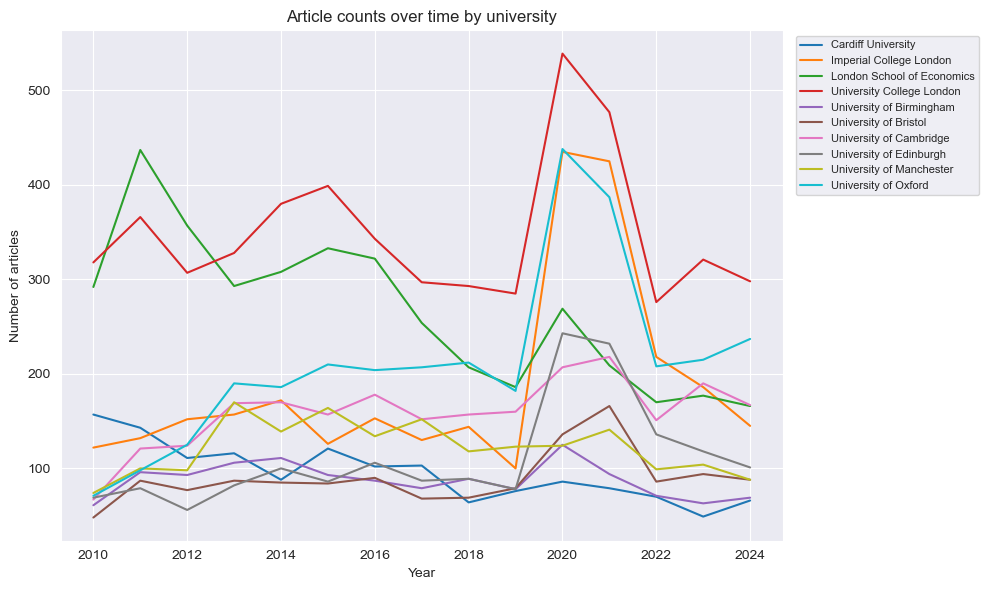

In [51]:
plt.figure(figsize=(10, 6))

for uni in counts['university'].unique():
    subset = counts[counts['university'] == uni]
    plt.plot(subset['year'], subset['article_count'], label=uni)

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.title("Article counts over time by university")
plt.xlabel("Year")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

These line charts demonstrate the article counts of 10 universities, and we can observe the changes and trends over time. 

The first observed pattern is a 'universal peak' of article counts around 2020, when most of the selected universities were mentioned in the media more frequently compared to other years. One major event that happened in 2020 was the breakout of COVID-19, which influenced the majority of the population in the UK, as well as university students. Due to COVID-19, universities had to adjust their teaching mode, i.e., switching to online classes. Together with other associated adjustments, COVID-19 could be a reasonable explanation for this universal increase.

The second observation is that UCL has overall the largest article counts over these years. This is very reasonable, as UCL is one of the most famous universities in the UK, and its size is comparatively larger than the others in this chart, i.e., LSE, Oxford, and Imperial.

Third, we find that some universities display different trends in terms of their article counts. For example, LSE shows a downward trend, and Imperial College shows an upward trend. 

In other times, the article counts of universities almost follow a similar trend. This implies the frequency of news and reports on universities is affected by larger-scale social issues, like COVID-19.

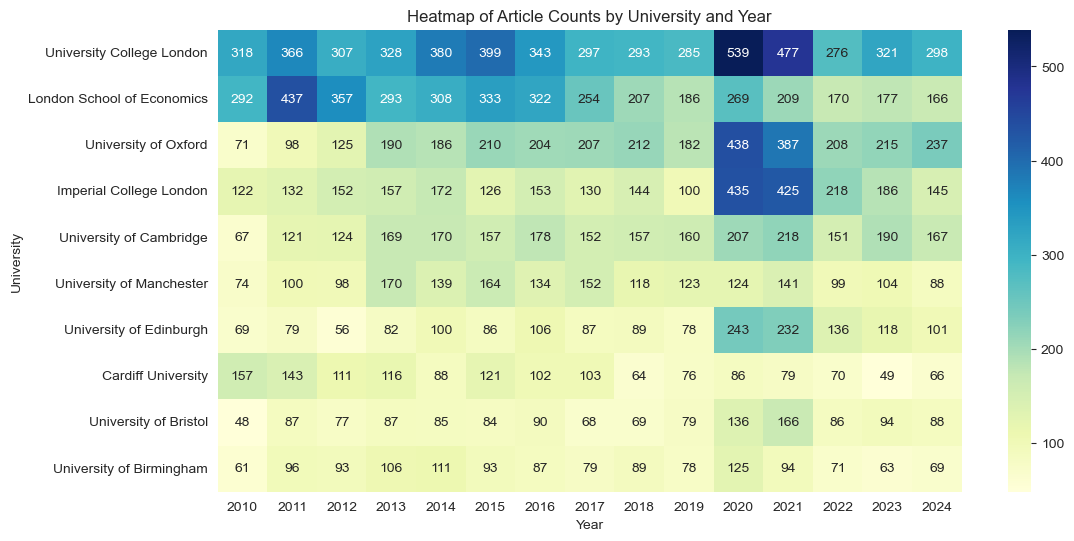

In [77]:
pivot = counts.pivot(
    index='university', 
    columns='year', 
    values='article_count'
).fillna(0)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot, 
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Heatmap of Article Counts by University and Year")
plt.xlabel("Year")
plt.ylabel("University")

plt.show()

This heatmap demonstrates the same information from the line chart, but tells more explicitly about the comparative number of articles related to different universities in different years. From this chart, we can see that there are more articles related to universities in the years 2020 and 2021; and over this 15-year time interval, the top 5 UK universities ('top' in terms of general reputation) have more media coverage than others.

### 4.1.2 Overlay of major events on the time series

### Major UK events and university coverage

To investigate whether major events produce spikes in university-related coverage, we selected 14 events from 2010–2024 that are either directly connected to higher education or are significant national events that could generate university commentary. Where multiple events fell in the same year, we grouped them together. We categorised them into two groups:

Events directly affecting universities (8): the austerity budget and tuition fee protests in 2010 (fees tripled to £9,000), the start of the new fee regime in 2012, the Scottish independence referendum in 2014 (which affected Scottish university funding and cross-border fees), the Brexit referendum in 2016 (threatening EU research funding and student mobility), Brexit being passed in 2019, the COVID-19 first lockdown and A-level results algorithm controversy in 2020, the third lockdown in 2021, the cost of living crisis in 2022 (which triggered student rent strikes), and the peak of UCU strikes in 2023.

Major national events (6): the 2011 England riots, the 2012 London Olympics, same-sex marriage legislation in 2013, the 2015 Conservative majority, the Grenfell Tower fire and snap election in 2017, and the 2024 Labour election victory.

By comparing these two groups on the same chart, we can examine whether education-related events drive more visible changes in university coverage than general national news.

In [48]:
#events grouped by whether they directly affect universities
events = pd.DataFrame({
    'event': ['Austerity / Tuition fee protests', 
              'England riots', 'New fee regime / London Olympics',
              'Same-sex marriage', 'Scottish independence ref',
              'Conservative majority', 'Brexit referendum',
              'Grenfell Tower / Snap election', 'Brexit passed',
              'First COVID lockdown / A-level algorithm row', 'Third lockdown',
              'Cost of living crisis / Queen Elizabeth dies', 
              'UCU strikes peak', 'Labour wins election'],
    'year': [2010, 2011, 2012, 2013, 2014,
             2015, 2016, 2017, 2019,
             2020, 2021, 2022, 2023, 2024],
    'type': ['direct', 'national', 'direct', 'national', 'direct',
             'national', 'direct', 'national', 'direct',
             'direct', 'direct', 'direct', 'direct', 'national']
})

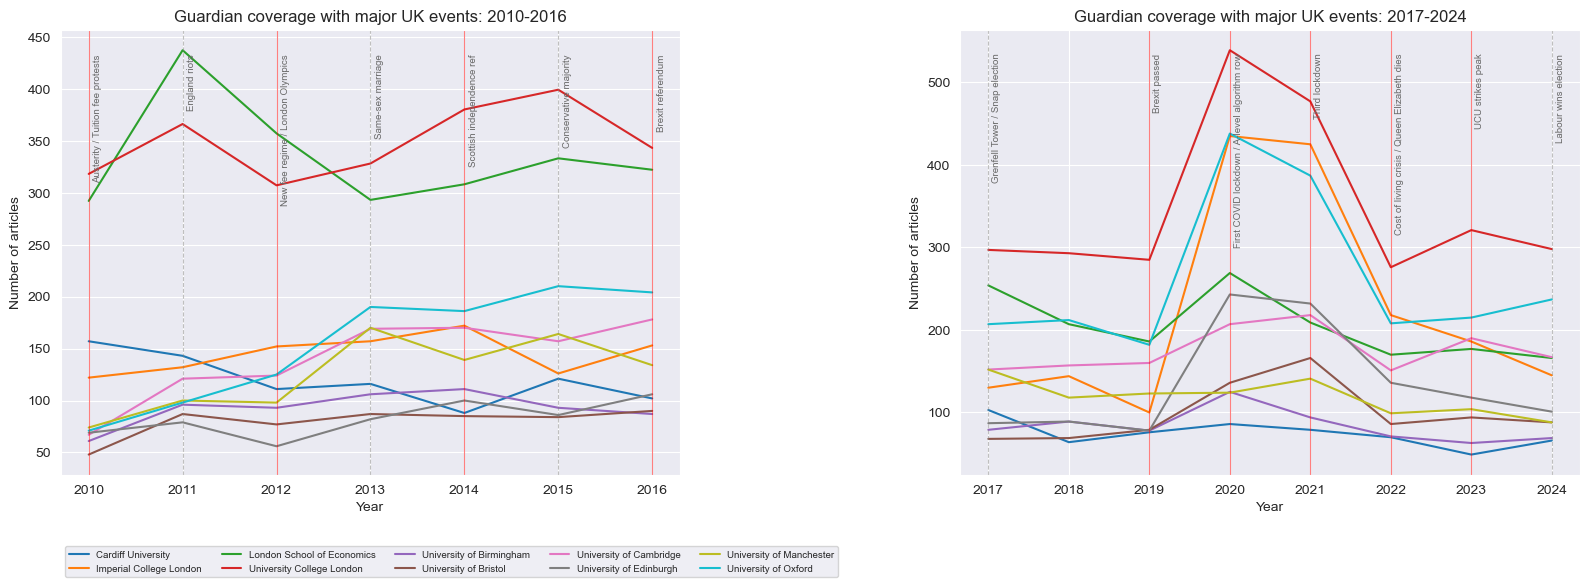

In [49]:
#overlay events on time series - split into two periods for readability
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, year_range, title in [
    (axes[0], range(2010, 2017), '2010-2016'),
    (axes[1], range(2017, 2025), '2017-2024')
]:
    for uni in counts['university'].unique():
        subset = counts[counts['year'].isin(year_range)]
        uni_data = subset[subset['university'] == uni]
        ax.plot(uni_data['year'], uni_data['article_count'], label=uni)
    
    period_events = events[events['year'].isin(year_range)]
    for _, row in period_events.iterrows():
        if row['type'] == 'direct':
            ax.axvline(x=row['year'], color='red', linestyle='-', linewidth=0.8, alpha=0.5)
        else:
            ax.axvline(x=row['year'], color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.text(row['year'] + 0.05, ax.get_ylim()[1] * 0.95, row['event'],
                rotation=90, fontsize=7, va='top', color='dimgrey')
    
    ax.set_title(f'Guardian coverage with major UK events: {title}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of articles')
    ax.set_xticks(list(year_range))

axes[0].legend(bbox_to_anchor=(0, -0.15), loc='upper left', fontsize=7, ncol=5)
plt.tight_layout()
plt.show()

The overlay reveals a clear pattern: events that directly affect universities produce more visible changes in coverage than general national events.

The COVID-19 lockdowns in 2020 and 2021 caused the largest spike across nearly all universities — article counts roughly doubled compared to 2019. This is expected because COVID directly disrupted teaching, assessment, and student welfare. The 2010 tuition fee protests also correspond to a period of increased coverage, though the effect is harder to isolate since it was our first year of data.

In contrast, major national events like Brexit (2016), the London Olympics (2012), and the death of Queen Elizabeth II (2022) do not produce noticeable spikes in university-related article counts. This suggests that the Guardian's university coverage is driven more by events that directly affect higher education than by general national news, even when those events are highly significant.

One notable exception is the 2011 England riots, which coincide with a peak in LSE's coverage relative to other universities. This likely reflects LSE's role as a leading social science institution — its researchers were heavily involved in analysing the causes of the riots, generating media attention for the university specifically.

This analysis has limitations: article counts are aggregated at the yearly level, so we cannot identify spikes at the monthly or weekly level where shorter-term events might show a clearer effect.

### 4.1.3 COVID-19 impact comparison

We have observed a big picture of trends in the number of articles related to universities, and we have analysed factors and social events that caused these changes. Now we will demonstrate the movements of data and trends.

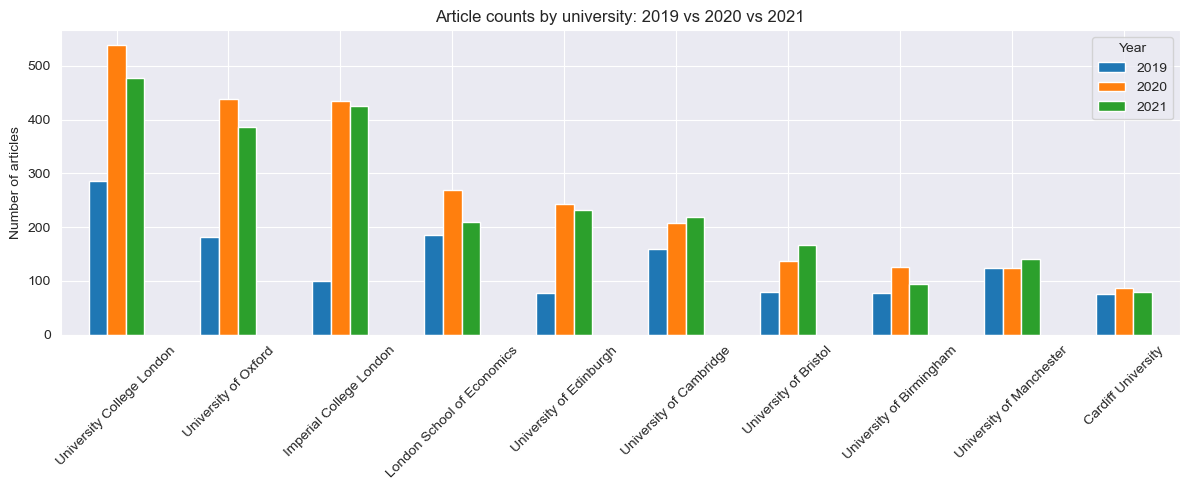

In [53]:
#compare article counts around COVID: 2019 vs 2020 vs 2021
years_to_compare = counts[counts['year'].isin([2019, 2020, 2021])]
pivot_covid = years_to_compare.pivot(index='university', columns='year', values='article_count').fillna(0)
pivot_covid = pivot_covid.sort_values(2020, ascending=False)

pivot_covid.plot(kind='bar', figsize=(12, 5))
plt.title('Article counts by university: 2019 vs 2020 vs 2021')
plt.ylabel('Number of articles')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

From the above bar chart, we found that most of the universities experienced an increase in the number of articles related to them, and in some cases, the increases are close to double and triple. In general, the larger the total amount of media coverage is, the more obvious the increase is. The last 5 universities showed less representative and less obvious increasing trends from 2019 to 2020 and 2021 compared to the top 5 universities. This internal difference could be explained by the size and scale of both the university itself and the amount of media reports related to it.

In [73]:
#lowercase titles for keyword matching
clean_df['webTitle'] = clean_df['webTitle'].str.lower()

## 4.2 Themes and Keyword Analysis


### Section breakdown

In [74]:
#count articles by university and section
uni_section = pd.crosstab(clean_df['university'], clean_df['sectionName'])

### Section coverage and Article count per university

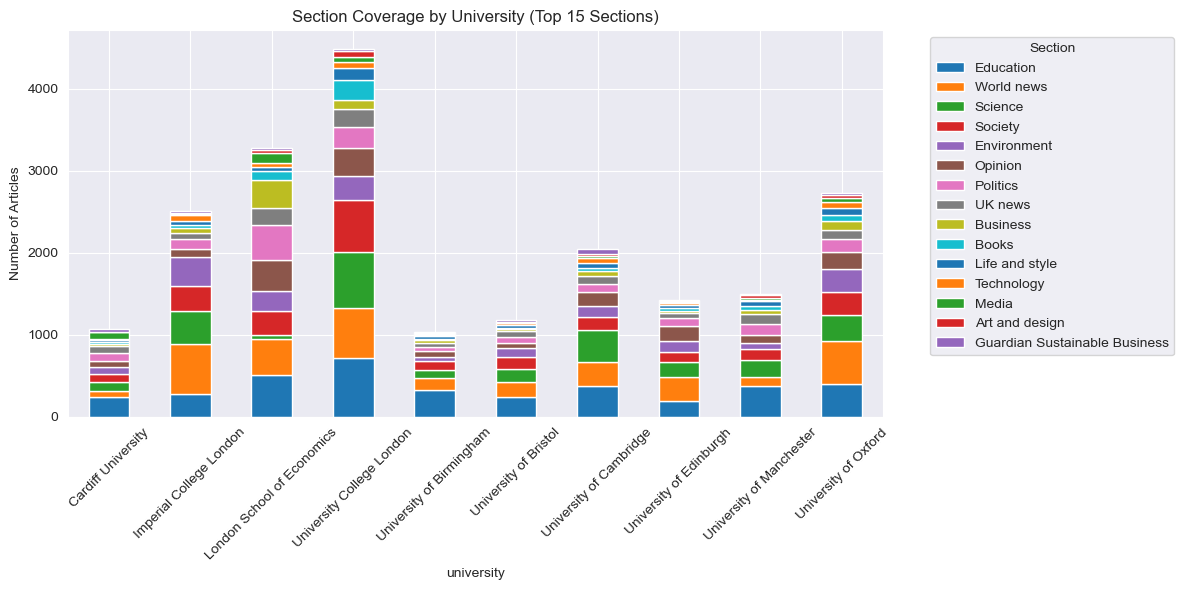

In [65]:
#need to put them all into one and colour coded so that it is easier to compare

top_sections = uni_section.sum().sort_values(ascending=False).head(15).index
filtered = uni_section[top_sections]

filtered.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Section Coverage by University (Top 15 Sections)")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.legend(title="Section", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

We decided to only use the top 15 sections for each university or else the data gets too much and there is not much useful analysis that can be done. 

When comparing all the universities simultaneously using a stacked chart, the majority of Articles covered for all of them are Education, World News and Science. It is also easier to see the difference in the number of raw articles produced for each university as well - UCL and LSE leading with the most articles written. Cardiff, Birmingham and Bristol have the lowest amount of articles, but it is still above 1000 per university. This means the universities with a lot more articles written can visually dominate the stacked chart. This means normalising the proportions is important to get a clearer overview, which we have done next. 

Across all ten universities, the most common sections covered are 'Education' and 'World news'. But looking at the underlying data, you can also see the individuality of each of the universities from some key differences.
Starting with LSE, after 'Education' and 'World news', the most covered sections are 'Politics', 'Opinion' and 'Business'. This aligns with what the university is known for - social science and the political relevance of its research output. Oxford and Cambridge appear frequently across a variety of sections, especially 'Science' and 'Society', separating them from specialist universities. Imperial College London is also a good example of a specialist university, being widely covered in 'Science', which shows it is known for its STEM courses. Universities such as Cardiff have a more even spread across fewer sections, which could possibly reflect a lower total article volume rather than focusing on what they are known for.
These differences show that Guardian coverage of universities depends on each university's subject strengths and public reputation, not just on its size.

Sections where all universities have >20 articles: 9
['Education', 'Environment', 'Life and style', 'Opinion', 'Politics', 'Science', 'Society', 'UK news', 'World news']


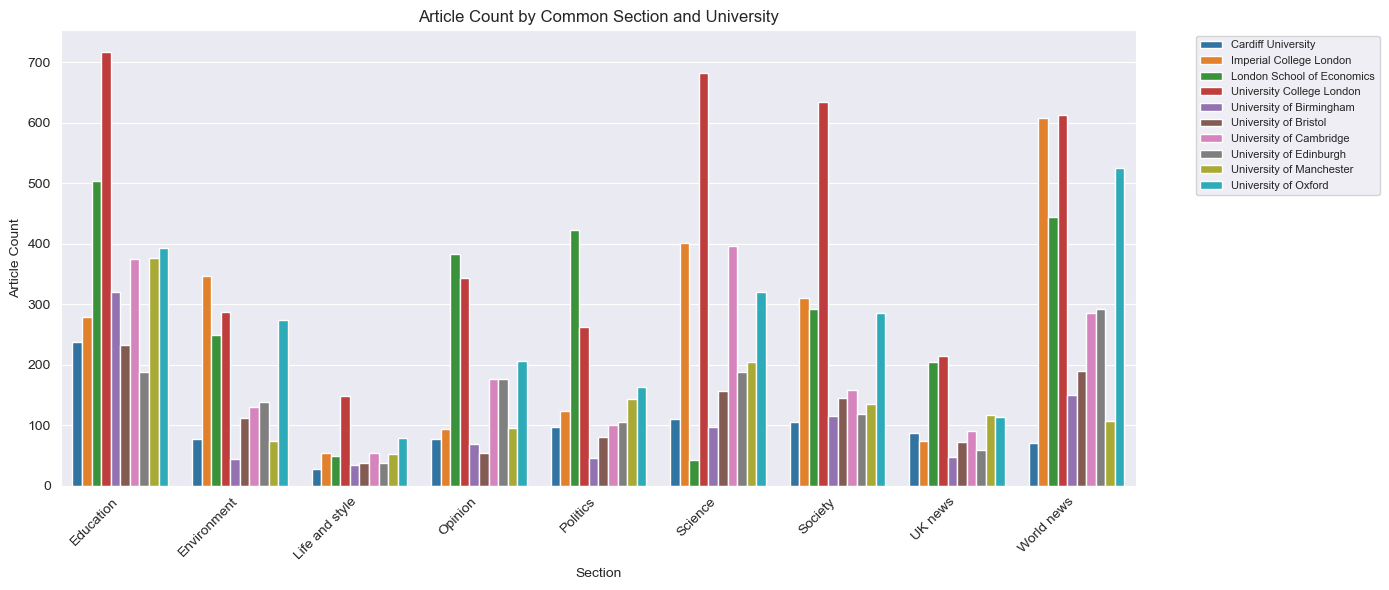

In [31]:
# categorising further so it is only section names all the universities have in common and only the ones with more than 20 articles each
common_section_names = uni_section.columns[uni_section.min(axis=0) > 20].tolist()
print(f"Sections where all universities have >20 articles: {len(common_section_names)}")
print(common_section_names)
common = uni_section[common_section_names]


common_reset = common.reset_index()
common_melted = common_reset.melt(id_vars='university', var_name='Section', value_name='Article Count')

plt.figure(figsize=(14, 6))
sns.barplot(data=common_melted, x='Section', y='Article Count', hue='university')
plt.title('Article Count by Common Section and University')
plt.xlabel('Section')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

The stacked chart showed 15 sections for each of the universities, which made it difficult to compare the individual sections covered by the universities. So instead, we filtered the data to show sections where each university has more than at least 20 articles and then filtered further so that only the sections all ten universities had in common were shown in the bar chart. This narrowed it down to nine sections. Plotting the bars for all the universities for each section side by side makes it more visually pleasing as well as easier to compare.

The short list of sections shows how uneven cross-university coverage is (few themes generate substantial coverage across all ten), and the fact that most sections are dominated by a few universities. This matters methodologically — it means simple section comparisons risk reflecting the Guardian's editorial emphasis on particular universities rather than genuine thematic differences.

### 4.2.1 Keyword Frequency Analysis

Our research questions ask about politics vs education vs events, the differences between universities and spikes around major events such as COVID-19. So we picked a keyword set that relates to these individual themes and stored it in a dictionary mapping keyword lists to category names.

In [33]:
#keyword dictionary to find in titles
keywords = {
    "tuition_fees": ["tuition", "fees", "student debt", "budget"],
    "research": ["research", "study", "scientists", "discovery"],
    "rankings": ["ranking", "ranked", "top university", "league table"],
    "politics": ["government", "policy", "minister", "brexit", "regulation"],
    "covid": ["covid", "pandemic", "lockdown", "coronavirus"],
    "strike": ["strike", "union", "walkout", "industrial action"],
    "international": ["international", "overseas", "visa", "foreign students", "immigration"],
    "funding": ["funding", "investment", "cuts"]
}

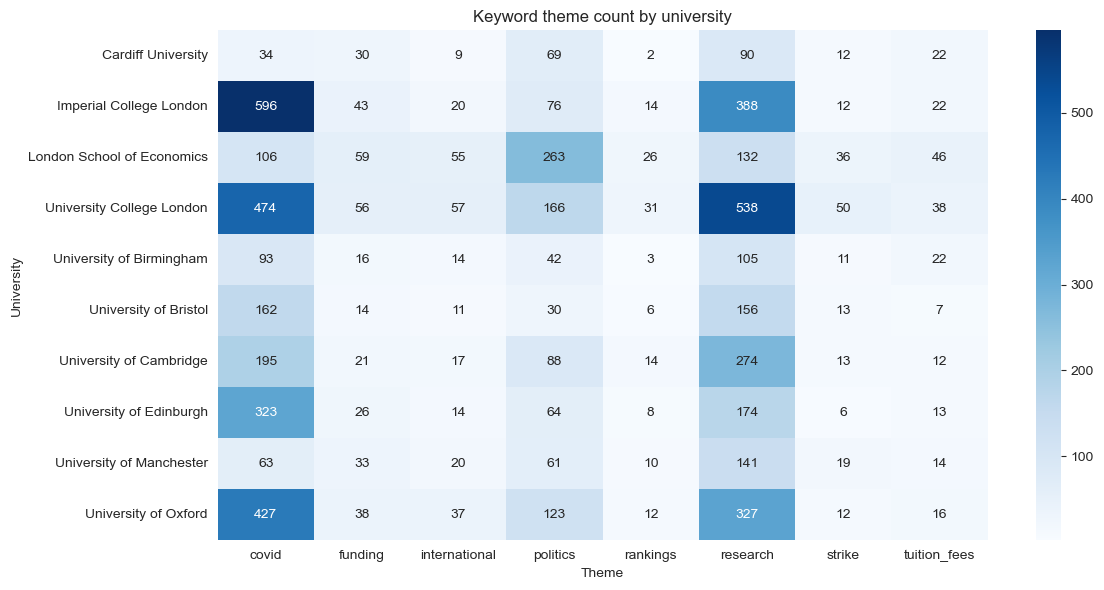

In [75]:
results = []

for uni in clean_df['university'].unique():
    subset = clean_df[clean_df['university'] == uni]
    
    for category, words in keywords.items():
        # join keywords with | so str.contains matches any of them
        pattern = "|".join(words)
        count = subset['webTitle'].str.contains(pattern, case=False, na=False).sum()
        results.append({
            "university": uni,
            "category": category,
            "count": count
        })

keyword_df = pd.DataFrame(results) #storing in data frame

#keyword raw count heatmap

keyword_pivot = keyword_df.pivot(
    index='university',
    columns='category',
    values='count'
).fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(keyword_pivot, annot=True, cmap="Blues", fmt=".0f")
plt.title("Keyword theme count by university")
plt.ylabel("University")
plt.xlabel("Theme")
plt.tight_layout()
plt.show()

We used a raw keyword counts heatmap to see the actual number of times a keyword appeared in the web title for a university article. From the heatmap, you can see that LSE and UCL have the highest keyword match for most of the themes. This is consistent with their high total article volume. The research category generates the most overall matches, which makes sense as the Guardian frequently mentions the research output of universities. In the international theme, LSE and UCL dominate, which reflects their large international student population and global research profiles. 

However, raw counts alone can be misleading (universities with more articles will score more), which is why the normalised view of the heatmap has been created below. 

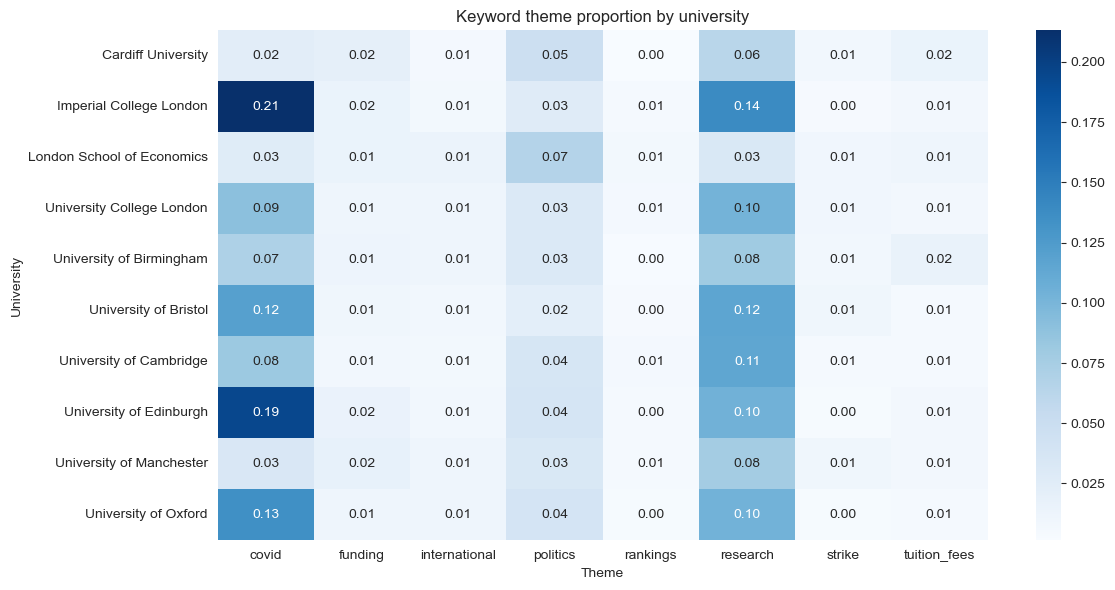

In [76]:
#normalised heatmap 
total_articles = clean_df['university'].value_counts()
keyword_pivot_norm = keyword_pivot.div(total_articles, axis=0)

plt.figure(figsize=(12, 6))
sns.heatmap(keyword_pivot_norm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Keyword theme proportion by university")
plt.ylabel("University")
plt.xlabel("Theme")
plt.tight_layout()
plt.show()

After normalising the keyword proportion (keyword count/total articles for the university), we can compare the themes more objectively between universities. 

We can see that LSE has a much larger proportion of articles under the theme of politics compared to other universities, which aligns with its reputation of being a university of social science and the frequent citation of LSE academics in political commentary. 
Imperial shows a higher proportion of research articles. You can see the absolute value after normalisation shows Imperial University's prominence in this theme, because with the raw count, it seemed like UCL dominated this section, but with the normalised heatmap, you can see this is not the case. 
Cardiff and Birmingham were two that had the lowest raw article count, but despite this, the normalised heatmap shows proportions broadly comparable to Oxford and Cambridge in many categories, suggesting coverage is thematically similar between these universities. 
The funding and tuition fees themes are almost equally spread between the universities, meaning they aren't associated with any one institution, just a wide spread category which is common to all the universities. 
Overall, the Guardian coverage reflects institutional identity - specialist universities such as LSE and Imperial have specific themes related to them compared to generalist universities. 

One of our research questions is 'How does coverage spike around major UK events?'. The keyword frequency heatmaps show that COVID-related keywords account for a large share of headline matches across most universities, suggesting that the pandemic generated substantial coverage. However, these heatmaps show aggregate counts over the full 2010–2024 period and cannot tell us when the spike occurred. The time-series analysis in Section 4.1 examines this directly by plotting article counts over time and overlaying major events.



### Explanatory visuals

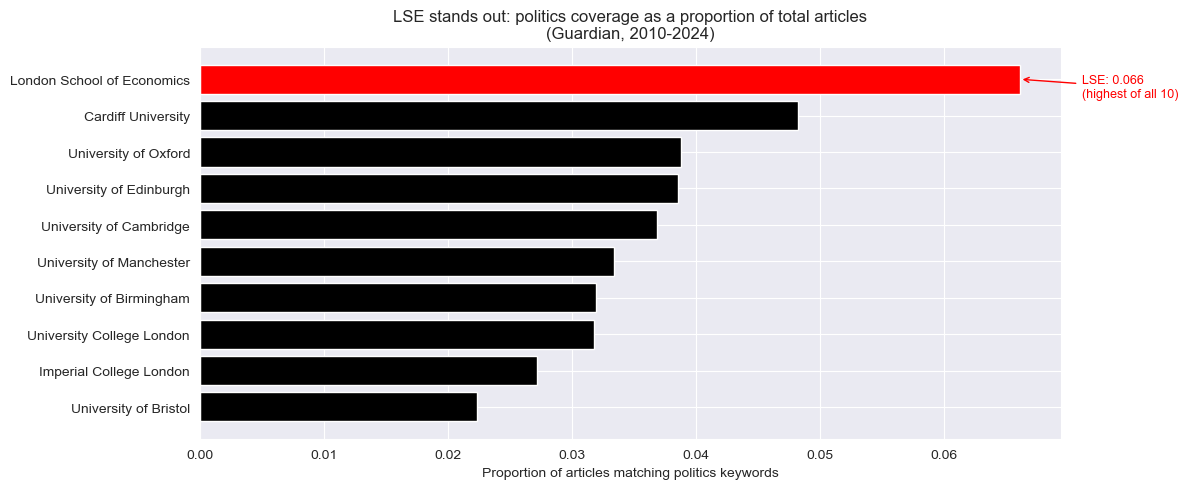

In [36]:
#explanatory plot: LSE's disproportional coverage in politics theme
fig, ax = plt.subplots(figsize=(12, 5))

politics_data = keyword_pivot_norm['politics'].sort_values(ascending=True)

#highlight LSE in red
colours = []
for uni in politics_data.index:
    if uni == 'London School of Economics':
        colours.append('red')
    else:
        colours.append('black')

ax.barh(politics_data.index, politics_data.values, color=colours)

#annotate LSE bar
lse_val = politics_data['London School of Economics']
lse_pos = list(politics_data.index).index('London School of Economics')
ax.annotate(
    f'LSE: {lse_val:.3f}\n(highest of all 10)',
    xy=(lse_val, lse_pos),
    xytext=(lse_val + 0.005, lse_pos - 0.5),
    fontsize=9,
    color='red',
    arrowprops=dict(arrowstyle='->', color='red')
)

ax.set_xlabel('Proportion of articles matching politics keywords')
ax.set_title('LSE stands out: politics coverage as a proportion of total articles\n(Guardian, 2010-2024)')
plt.tight_layout()
plt.show()

From this chart, you can see that LSE has a much higher share of politics-related headlines than any other Russell Group university. This is a clear reflection of LSE's reputation as the UK's leading social science institution. All other universities cluster between 2-4%, while LSE is above 6%. This finding holds after normalising for total article volume, confirming it is not an artefact of LSE's overall coverage level.

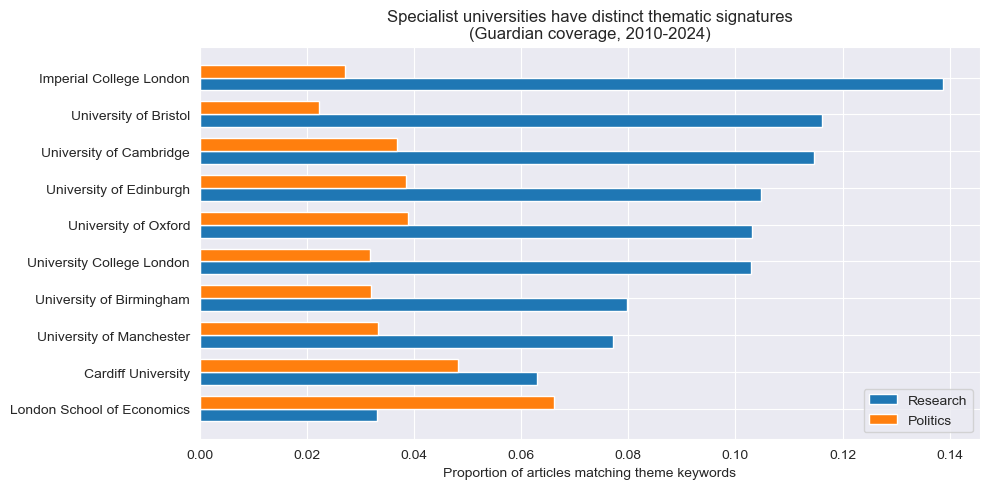

In [37]:
#explanatory plot: comparing research vs politics themes across universities
fig, ax = plt.subplots(figsize=(10, 5))

compare = keyword_pivot_norm[['research', 'politics']].copy()
compare = compare.sort_values('research', ascending=True)

x = range(len(compare))
bar_width = 0.35

ax.barh([i - bar_width/2 for i in x], compare['research'], bar_width, label='Research')
ax.barh([i + bar_width/2 for i in x], compare['politics'], bar_width, label='Politics')

ax.set_yticks(list(x))
ax.set_yticklabels(compare.index)
ax.set_xlabel('Proportion of articles matching theme keywords')
ax.set_title('Specialist universities have distinct thematic signatures\n(Guardian coverage, 2010-2024)')
ax.legend()

plt.tight_layout()
plt.show()

This chart directly compares the research and politics keyword proportions across all 10 universities. The contrast between Imperial (highest research proportion) and LSE (highest politics proportion) illustrates how specialist universities receive coverage that reflects their institutional identity. Generalist universities like Oxford and Cambridge sit in the middle on both themes, consistent with their broader academic scope.

# 5 Conclusion

This section summarises our findings against each research question, discusses limitations of our approach, and suggests directions for future work.

## 5.1 Summary of findings

This project analysed Guardian newspaper coverage of 10 Russell Group universities between 2010 and 2024, using a dataset of 25,142 articles collected via the Guardian API. Our findings against each research question are summarised below.

### RQ1: Which universities receive the most coverage, and how has this changed over time?

In terms of raw article counts, UCL received the most coverage (5,227 articles), followed by LSE (3,980) and Oxford (3,170). Cardiff and Bristol received substantially less coverage than the London-based institutions.

From an initial inspection of the data, the number of articles varies over time rather than following a consistent upward or downward trend. There is a noticeable increase in coverage around 2020–2021, followed by a decline in later years. This suggests that media attention towards universities fluctuates and may be influenced by external factors or specific periods of heightened interest, rather than exhibiting a stable long-term pattern.

### RQ2: What themes dominate coverage, and do they differ across institutions?

Sectional-level analysis shows that 'Education' and 'World news' are the dominant categories across all ten universities. However, thematic signatures differ significantly between different universities, depending mostly on whether the institution is specialised or generalised and the total raw number of articles each university has. After normalising for total article volume, LSE clearly has a disproportionately high number of articles related to politics, and Imperial is associated more with research and science themes. The keyword analysis confirms these patterns at the headline level: LSE's politics proportion is the highest of all 10 universities, and Imperial's research proportion is much higher compared to its politics proportion. These differences are consistent with each university's subject specialisation. 

### RQ3: How does coverage spike around major UK events?

The keyword frequency heatmaps show that COVID-related terms account for a large proportion of headline matches across almost all universities, indicating that the pandemic was a major driver of university-related coverage. However, the heatmaps alone cannot identify when these spikes occurred. The time-series analysis (Section 4.1) addresses this directly, showing that the 2020–2021 spike in total article counts coincides with the COVID-19 pandemic, and that this pattern is consistent across most universities. The strike and funding themes show comparatively little variation, suggesting that not all major events generate the same level of media response.

## 5.2 Limitations

Some of the limitations of our project include:
- Our keyword analysis relies on matching terms in article titles only. Headlines are often brief and may not reflect the full content of an article — a piece primarily about student mental health might not use any of our keyword terms in its title. This likely underestimates coverage of some themes.
- As identified in the IDA stage, 21.5% of articles appear under multiple universities. This means per-university keyword counts may include articles that are not primarily about that institution but mention it alongside others.
- Our keyword categories are manually defined and may not capture all relevant terms. For example, the "politics" category includes "brexit" and "minister" but may miss articles framed around "parliament" or "legislation".
- The Guardian is a single news source with its own editorial perspective. Coverage patterns may differ in other outlets, so our findings reflect how the Guardian covers universities, not media coverage in general.

## 5.3 Suggestions for future work

- Analyse the full body text of articles rather than just headlines, which would give a more complete picture of thematic coverage. The bodyText data was collected but excluded from the CSV due to file size — it can be reproduced by re-running data_collection.ipynb.
- Apply natural language processing techniques such as topic modelling to identify themes in article text without relying on predefined keyword lists.
- Compare coverage across multiple UK newspapers (e.g. Guardian vs Telegraph) to examine whether political leaning of the outlet affects how universities are portrayed.
- Incorporate article engagement data (e.g. comment counts, shares) if available, to assess not just what is covered but what generates public discussion.
- Combine Guardian coverage data with external datasets such as HESA enrolment statistics or university ranking data to investigate whether coverage volume correlates with institutional size, research output, or ranking position.